In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [2]:
X, y = make_blobs(n_samples=500, n_features=2, centers=5, random_state=3)

print("Shape of X:", X.shape)

Shape of X: (500, 2)


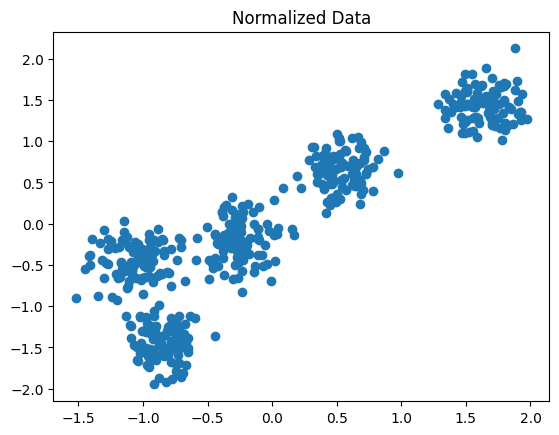

In [3]:
def normalize(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mean) / std

X = normalize(X)

plt.scatter(X[:, 0], X[:, 1])
plt.title("Normalized Data")
plt.show()

In [4]:
k = 5
colors = ["green", "red", "blue", "yellow", "orange"]
n_features = X.shape[1]

def init_centroids(X, k):
    centroids = {}
    for i in range(k):
        # pick random data point as initial centroid
        center = X[np.random.randint(0, X.shape[0])]
        
        centroids[i] = {
            "center": center,
            "color": colors[i],
            "points": []
        }
    return centroids

In [5]:
def distance(p, q):
    return np.sqrt(np.sum((p - q) ** 2))

In [6]:
def assign_points(X, centroids):
    # clear previous points
    for kx in centroids:
        centroids[kx]["points"] = []
        
    for point in X:
        distances = []
        for kx in centroids:
            d = distance(point, centroids[kx]["center"])
            distances.append(d)
        
        cluster_id = np.argmin(distances)
        centroids[cluster_id]["points"].append(point)

In [7]:
def update_centroids(centroids):
    converged = True
    
    for kx in centroids:
        pts = np.array(centroids[kx]["points"])
        
        if len(pts) > 0:
            old_center = centroids[kx]["center"].copy()
            new_center = pts.mean(axis=0)
            centroids[kx]["center"] = new_center
            
            if not np.allclose(old_center, new_center):
                converged = False
                
    return converged

In [25]:
def kmeans(X, k, max_iters=100):
    centroids = init_centroids(X, k)
    
    for i in range(max_iters):
        assign_points(X, centroids)
        converged = update_centroids(centroids)
        
        if converged:
            print(f"Converged in {i+1} iterations")
            break
            
    return centroids

In [26]:
def plot_clusters(centroids):
    for kx in centroids:
        pts = np.array(centroids[kx]["points"])
        
        if len(pts) > 0:
            plt.scatter(pts[:, 0], pts[:, 1], color=centroids[kx]["color"])
        
        center = centroids[kx]["center"]
        plt.scatter(center[0], center[1], color="black", marker="*", s=200)
    
    plt.title("K-Means Clustering (Final)")
    plt.show()

Converged in 9 iterations


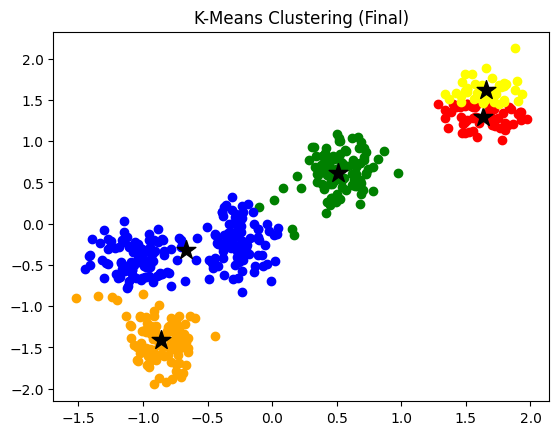

In [27]:
centroids = kmeans(X, k)
plot_clusters(centroids)